# Stage 4 - Sentiment analysis

Label each comment positive / negative / neutral. We use **VADER** as the main one because it's
built for social media (handles emojis-as-words, caps, !!! etc) and is fast enough for 20k rows.
We also show TextBlob polarity (used in Lab 1) so we can compare the two in the report.

The sentiment label is reused in stage 5 to do topic modeling *per sentiment*.

In: `../data/comments_meta.csv`  Out: `../data/comments_sentiment.csv`

In [1]:
import pandas as pd
import nltk
nltk.download("vader_lexicon")
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Saeed\AppData\Roaming\nltk_data...


In [2]:
df = pd.read_csv("../data/comments_meta.csv").dropna(subset=["clean_text"]).reset_index(drop=True)
print(len(df), "comments")

18771 comments


## VADER

We score the *original* text (not lemmas) so VADER can see punctuation/caps it relies on.

In [3]:
sia = SentimentIntensityAnalyzer()

def vader_label(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    return "neutral"

df["vader_score"] = df["text"].apply(lambda t: sia.polarity_scores(str(t))["compound"])
df["sentiment"] = df["vader_score"].apply(
    lambda s: "positive" if s >= 0.05 else ("negative" if s <= -0.05 else "neutral"))
df["sentiment"].value_counts()

sentiment
neutral     10935
positive     5764
negative     2072
Name: count, dtype: int64

In [4]:
# textblob for comparison
df["textblob_polarity"] = df["clean_text"].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
df[["text", "vader_score", "sentiment", "textblob_polarity"]].head(10)

,text,vader_score,sentiment,textblob_polarity
0,Our Apple iOS 18.2 review is up now: https://y...,0.0000,neutral,0.00000
1,Is Apple in the red? Because what do you mean ...,0.0000,neutral,-0.15625
2,5years of software support when sansung budget...,0.4019,positive,0.00000
3,Can someone please buy me iPhone please 🥺,0.5574,positive,0.00000
4,This is such a pos. Everytime I pick it up I f...,0.3612,positive,0.07500
5,I’m upgrading my iphone 6s plus to iphone 16 n...,0.4795,positive,0.12500
6,I want to upgrade my 12 to a 16 because I’m co...,0.4215,positive,0.30000
7,@S@ShiB88 is good. Big upgrade for me,0.4404,positive,0.35000
8,Just got a 16 after holding on to my 2nd Gen S...,0.2023,positive,0.00000
9,Rhf,0.0000,neutral,0.00000


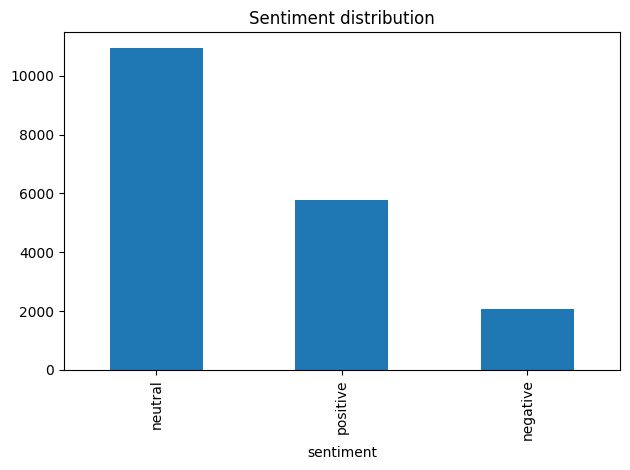

In [5]:
import matplotlib.pyplot as plt
df["sentiment"].value_counts().plot(kind="bar", title="Sentiment distribution")
plt.tight_layout()
plt.show()

## Optional - transformer sentiment

For the report we can also run a proper transformer model (cardiffnlp twitter-roberta) on a sample
and compare against VADER. Needs `transformers` + a download so it's off by default.

In [9]:
USE_TRANSFORMER = True

if USE_TRANSFORMER:
    from transformers import pipeline
    clf = pipeline("sentiment-analysis",
                   model="cardiffnlp/twitter-roberta-base-sentiment-latest")
    sample = df.sample(200, random_state=1).copy()
    sample["hf_sentiment"] = [r["label"] for r in clf(sample["clean_text"].tolist(), truncation=True)]
    print(sample["hf_sentiment"].value_counts())

c:\Users\Saeed\Documents\370\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25125.32it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


hf_sentiment
neutral     133
positive     34
negative     33
Name: count, dtype: int64


In [10]:
df.to_csv("../data/comments_sentiment.csv", index=False)
print("saved ->", "../data/comments_sentiment.csv")

saved -> ../data/comments_sentiment.csv
